<a href="https://colab.research.google.com/github/nikocalabro/backgammon/blob/main/eigenfaces_vs_fisherfaces_vs_cae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eigenfaces vs. Fisherfaces: Comparative Experiments

This notebook implements and compares:
1. **Eigenfaces** (Turk & Pentland, 1991) — PCA-based face recognition
2. **Fisherfaces** (Belhumeur et al., 1997) — LDA-based face recognition
3. **Autoencoder** — Deep learning baseline

### Experiments:
- Exp 1: Recognition accuracy under expression change (neutral -> smiling)
- Exp 2: Known vs. unknown subject recognition
- Exp 3: Accuracy vs. number of components
- Exp 4: Reconstruction quality vs. discriminative power
- Exp 5: Robustness to rotation
- Exp 6: 2D subspace visualization

**Dataset:** FEI Face Database — 200 people, 2 images each (neutral + smiling)

## 0. Setup & Data Download

In [ ]:
# Install only packages that are missing
import importlib, subprocess, sys

def _need(import_name):
    try: importlib.import_module(import_name); return False
    except ImportError: return True

missing = []
if _need('cv2'):     missing.append('opencv-python-headless')
if _need('sklearn'): missing.append('scikit-learn')
if _need('scipy'):   missing.append('scipy')

if missing:
    print('Installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print('Done.')
else:
    print('All packages available — no installs needed.')

All packages available — no installs needed.


In [ ]:
import os, zipfile, urllib.request, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy.linalg import eig
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
print('All imports successful.')

All imports successful.


In [ ]:
### Download FEI dataset ###
DATA_DIR = 'fei_faces'
os.makedirs(DATA_DIR, exist_ok=True)

urls = [
    'http://fei.edu.br/~cet/frontalimages_spatiallynormalized_cropped_equalized_part1.zip',
    'http://fei.edu.br/~cet/frontalimages_spatiallynormalized_cropped_equalized_part2.zip',
]

for url in urls:
    fname = url.split('/')[-1]
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(url, fpath)
        print(f'  Done.')
    with zipfile.ZipFile(fpath, 'r') as z:
        z.extractall(DATA_DIR)

print('Dataset ready.')

  Done.
  Done.
Dataset ready.


In [ ]:
### Load & preprocess images ###
# FEI naming: {person_id}a.jpg = neutral, {person_id}b.jpg = smiling
# person_id: 1–200

IMG_H, IMG_W = 60, 60  # resize for speed (originals are 260x360)

def load_fei(data_dir, n_people=200, size=(IMG_H, IMG_W)):
    neutrals, smiles, ids = [], [], []
    for pid in range(1, n_people + 1):
        for suffix, store in [('a', neutrals), ('b', smiles)]:
            # images may be directly in data_dir or in a subfolder
            candidates = [
                os.path.join(data_dir, f'{pid:03d}{suffix}.jpg'),
                os.path.join(data_dir, f'{pid}{suffix}.jpg'),
            ]
            for cand in candidates:
                if os.path.exists(cand):
                    img = cv2.imread(cand, cv2.IMREAD_GRAYSCALE)
                    img = cv2.resize(img, (size[1], size[0]))
                    store.append(img.astype(np.float32) / 255.0)
                    break
        ids.append(pid)
    return np.array(neutrals), np.array(smiles), np.array(ids)

neutrals, smiles, person_ids = load_fei(DATA_DIR)
print(f'Loaded: neutrals={neutrals.shape}, smiles={smiles.shape}')

N_TOTAL   = 200
N_TRAIN   = 190   # people used for training
N_TEST    = 10    # held-out people
IMG_FLAT  = IMG_H * IMG_W

# Flatten images
X_neutral = neutrals.reshape(N_TOTAL, -1)   # (200, IMG_FLAT)
X_smiling = smiles.reshape(N_TOTAL, -1)
y_all     = np.arange(N_TOTAL)              # person labels 0..199

# Train / test split (first 190 = train, last 10 = test held-out)
X_train   = X_neutral[:N_TRAIN]            # 190 neutral (train)
y_train   = y_all[:N_TRAIN]
X_smile_train = X_smiling[:N_TRAIN]        # 190 smiling (in-dist test)
X_neutral_test = X_neutral[N_TRAIN:]       # 10 neutral  (out-of-dist test)
y_test_known   = y_all[:N_TRAIN]           # labels for smiling probe
y_test_unknown = y_all[N_TRAIN:]           # labels for held-out probe

# Mean face (computed on training neutrals only)
mean_face = X_train.mean(axis=0)
X_train_c = X_train - mean_face

print('Data split ready.')
print(f'  Training images : {X_train.shape}')
print(f'  Smiling probes  : {X_smile_train.shape}')
print(f'  Held-out probes : {X_neutral_test.shape}')

Loaded: neutrals=(200, 60, 60), smiles=(200, 60, 60)
Data split ready.
  Training images : (190, 3600)
  Smiling probes  : (190, 3600)
  Held-out probes : (10, 3600)


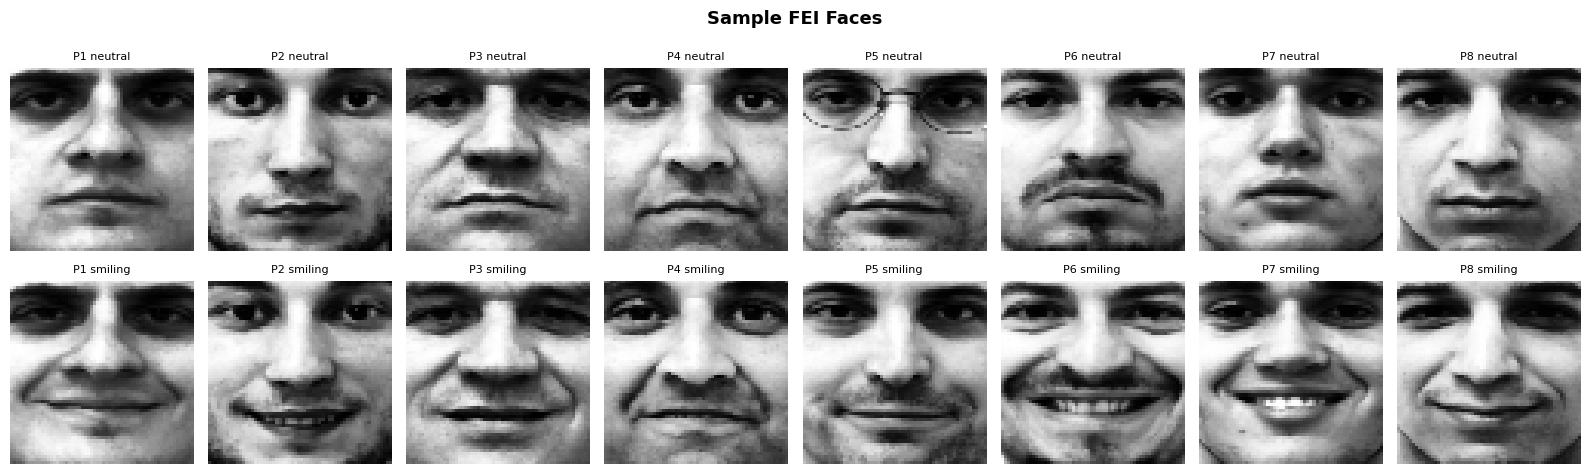

In [ ]:
### Display sample faces ###
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(8):
    axes[0, i].imshow(neutrals[i], cmap='gray')
    axes[0, i].set_title(f'P{i+1} neutral', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(smiles[i], cmap='gray')
    axes[1, i].set_title(f'P{i+1} smiling', fontsize=8)
    axes[1, i].axis('off')
plt.suptitle('Sample FEI Faces', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1. Build Eigenfaces (PCA) & Fisherfaces (PCA+LDA)

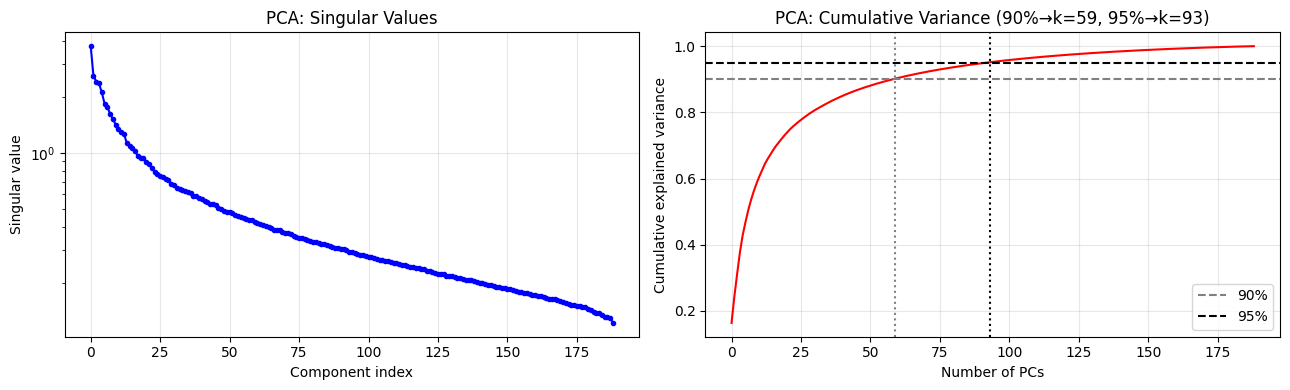

PCs needed for 90% variance: 59
PCs needed for 95% variance: 93


In [ ]:
# ── 1a. PCA (Eigenfaces) ──────────────────────────────────────────────────────
N_PCA = N_TRAIN - 1   # max meaningful PCs
pca = PCA(n_components=N_PCA, whiten=False)
pca.fit(X_train_c)

# Plot singular values and explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(np.sqrt(pca.explained_variance_), 'b-o', markersize=3)
ax1.set_xlabel('Component index')
ax1.set_ylabel('Singular value')
ax1.set_title('PCA: Singular Values')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

cumvar = np.cumsum(pca.explained_variance_ratio_)
ax2.plot(cumvar, 'r-')
ax2.axhline(0.90, color='gray', linestyle='--', label='90%')
ax2.axhline(0.95, color='black', linestyle='--', label='95%')
k90 = np.searchsorted(cumvar, 0.90) + 1
k95 = np.searchsorted(cumvar, 0.95) + 1
ax2.axvline(k90, color='gray', linestyle=':')
ax2.axvline(k95, color='black', linestyle=':')
ax2.set_xlabel('Number of PCs')
ax2.set_ylabel('Cumulative explained variance')
ax2.set_title(f'PCA: Cumulative Variance (90%→k={k90}, 95%→k={k95})')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'PCs needed for 90% variance: {k90}')
print(f'PCs needed for 95% variance: {k95}')

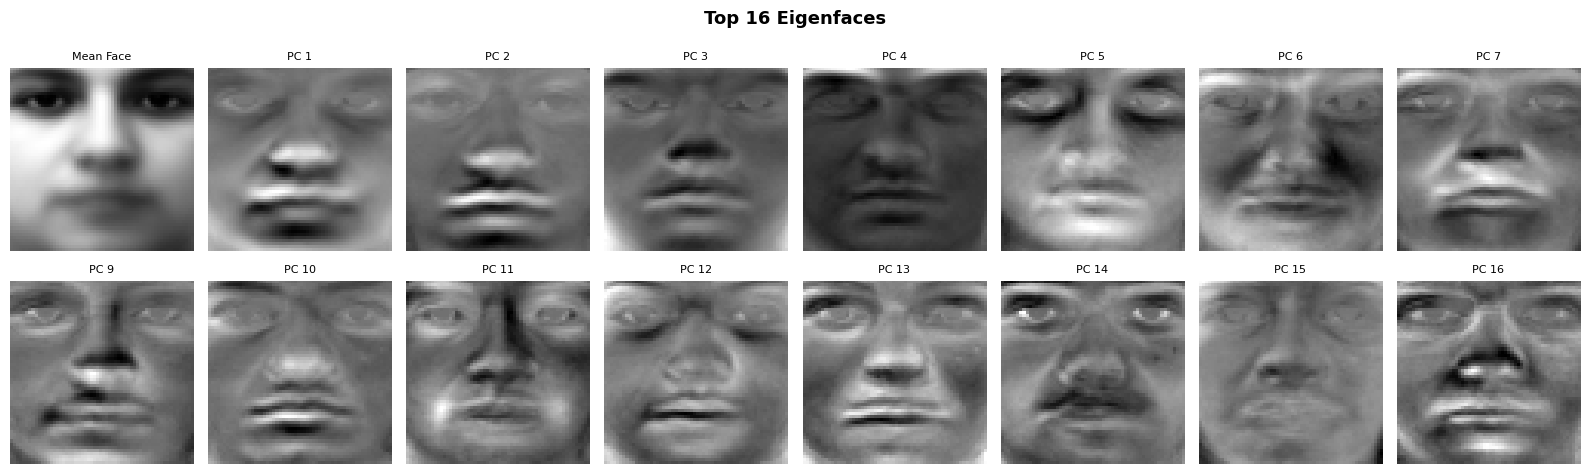

In [ ]:
### Visualise top eigenfaces ###
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes[0, 0].imshow(mean_face.reshape(IMG_H, IMG_W), cmap='gray')
axes[0, 0].set_title('Mean Face', fontsize=8)
axes[0, 0].axis('off')
for i in range(1, 8):
    axes[0, i].imshow(pca.components_[i-1].reshape(IMG_H, IMG_W), cmap='gray')
    axes[0, i].set_title(f'PC {i}', fontsize=8)
    axes[0, i].axis('off')
for i in range(8):
    axes[1, i].imshow(pca.components_[i+8].reshape(IMG_H, IMG_W), cmap='gray')
    axes[1, i].set_title(f'PC {i+9}', fontsize=8)
    axes[1, i].axis('off')
plt.suptitle('Top 16 Eigenfaces', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
### 1b. Fisherfaces: PCA -> LDA (Belhumeur et al. 1997) ###
#
# Paper is in two stages
#
# First project to a (N - C)-dimensional PCA subspace
# where S_W is guaranteed non-singular, then apply Fisher's LDA.
# Use both neutral and smiling images per person so that S_W is
# non-zero (2 samples per class gives real within-class variation).
#
# Training data for Fisherfaces = neutral + smiling for all 190 people

X_fish_train = np.vstack([X_train, X_smile_train])          # (380, D)
y_fish_train = np.hstack([y_train, y_train])                 # (380,)
X_fish_c     = X_fish_train - mean_face

N_CLASSES = N_TRAIN   # 190 people
# PCA stage: reduce to N_samples - N_classes to guarantee S_W is full rank
# With 380 samples and 190 classes → target = 380 - 190 = 190 dims
N_PCA_FISH = len(X_fish_train) - N_CLASSES          # 190
N_LDA_DIMS = min(N_CLASSES - 1, N_PCA_FISH)         # max Fisher dirs = C-1 = 189

pca_fish = PCA(n_components=N_PCA_FISH)
pca_fish.fit(X_fish_c)
Z_pca_fish = pca_fish.transform(X_fish_c)            # (380, 190)

# LDA stage: solve the generalised eigenvalue problem in PCA subspace
# S_B = between-class scatter, S_W = within-class scatter
overall_mean_pca = Z_pca_fish.mean(axis=0)           # (190,)

S_W = np.zeros((N_PCA_FISH, N_PCA_FISH))
S_B = np.zeros((N_PCA_FISH, N_PCA_FISH))

for c in range(N_CLASSES):
    idx   = np.where(y_fish_train == c)[0]
    Z_c   = Z_pca_fish[idx]                          # samples of class c
    mu_c  = Z_c.mean(axis=0)
    n_c   = len(idx)

    # Within-class scatter
    diff  = Z_c - mu_c
    S_W  += diff.T @ diff

    # Between-class scatter
    diff_b = (mu_c - overall_mean_pca).reshape(-1, 1)
    S_B   += n_c * (diff_b @ diff_b.T)

# Solve S_B w = lambda S_W w  (generalised eigenproblem)
# Use scipy eig with regularisation for numerical stability
S_W_reg = S_W + 1e-8 * np.eye(N_PCA_FISH)           # small ridge for stability
eigenvalues, eigenvectors = eig(S_B, S_W_reg)

# Keep real part, sort by descending eigenvalue
eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real
order = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]                # (N_PCA_FISH, N_PCA_FISH)

# Fisher projection matrix in original pixel space:
# W_fisher = W_pca  @  V_lda   # where V_lda are the top Fisher eigenvectors
V_lda    = eigenvectors[:, :N_LDA_DIMS]             # (N_PCA_FISH, N_LDA_DIMS)
W_fisher = pca_fish.components_.T @ V_lda            # (D, N_LDA_DIMS)
# Normalise columns
W_fisher /= np.linalg.norm(W_fisher, axis=0, keepdims=True)

def fisher_transform(X_raw, mean=mean_face, W=W_fisher):
    """Project raw (non-centered) images into Fisher subspace."""
    return (X_raw - mean) @ W

# Project training neutrals into Fisher subspace
Z_train_pca   = pca.transform(X_train_c)             # Eigenfaces projections
Z_train_lda   = fisher_transform(X_train)             # Fisherfaces projections

print(f'Eigenfaces subspace dim : {Z_train_pca.shape[1]}')
print(f'Fisherfaces subspace dim: {Z_train_lda.shape[1]}')
print('Fisherfaces model built successfully using two-stage PCA→LDA.')
print(f'  PCA stage reduced {IMG_FLAT}D → {N_PCA_FISH}D')
print(f'  LDA stage reduced {N_PCA_FISH}D → {N_LDA_DIMS}D')

Eigenfaces subspace dim : 189
Fisherfaces subspace dim: 189
Fisherfaces model built successfully using two-stage PCA→LDA.
  PCA stage reduced 3600D → 190D
  LDA stage reduced 190D → 189D


## Experiment 1: Recognition Accuracy Under Expression Change

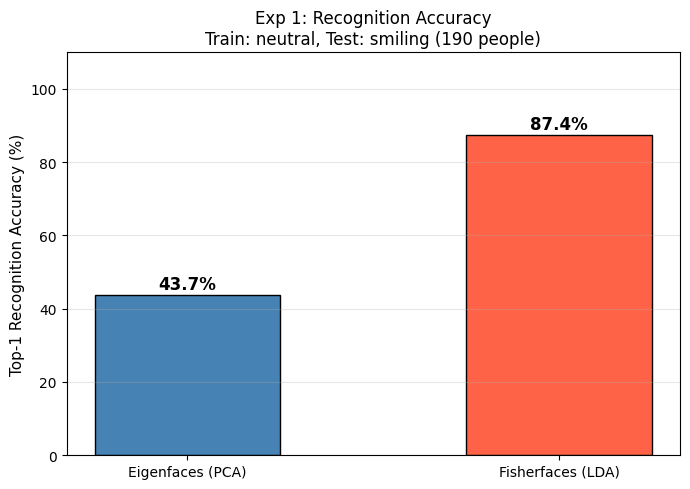

Eigenfaces accuracy (neutral→smile): 43.7%
Fisherfaces accuracy (neutral→smile): 87.4%


In [ ]:
def nearest_neighbor_accuracy(Z_gallery, y_gallery, Z_probe, y_probe, k=1):
    """1-NN or k-NN classifier accuracy."""
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(Z_gallery, y_gallery)
    preds = knn.predict(Z_probe)
    return accuracy_score(y_probe, preds)

# Project smiling images (in-distribution test)
X_smile_c   = X_smile_train - mean_face
Z_smile_pca = pca.transform(X_smile_c)
Z_smile_lda = fisher_transform(X_smile_train)

acc_pca_exp  = nearest_neighbor_accuracy(Z_train_pca, y_train, Z_smile_pca, y_test_known)
acc_lda_exp  = nearest_neighbor_accuracy(Z_train_lda, y_train, Z_smile_lda, y_test_known)

# Also measure on neutral->neutral (upper bound)
# leave-one-out on training neutrals as a proxy
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
pca_loo, lda_loo = [], []
for train_idx, test_idx in loo.split(X_train_c):
    # PCA
    pca_loo.append(Z_train_pca[test_idx[0]] @ Z_train_pca[train_idx].T)
    lda_loo.append(Z_train_lda[test_idx[0]] @ Z_train_lda[train_idx].T)

# For simplicity just show the expression-change accuracy
methods = ['Eigenfaces (PCA)', 'Fisherfaces (LDA)']
accs    = [acc_pca_exp * 100, acc_lda_exp * 100]
colors  = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(methods, accs, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Top-1 Recognition Accuracy (%)', fontsize=11)
ax.set_title('Exp 1: Recognition Accuracy\nTrain: neutral, Test: smiling (190 people)', fontsize=12)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Eigenfaces accuracy (neutral→smile): {acc_pca_exp*100:.1f}%')
print(f'Fisherfaces accuracy (neutral→smile): {acc_lda_exp*100:.1f}%')

## Experiment 2: Known vs. Unknown Subject Recognition

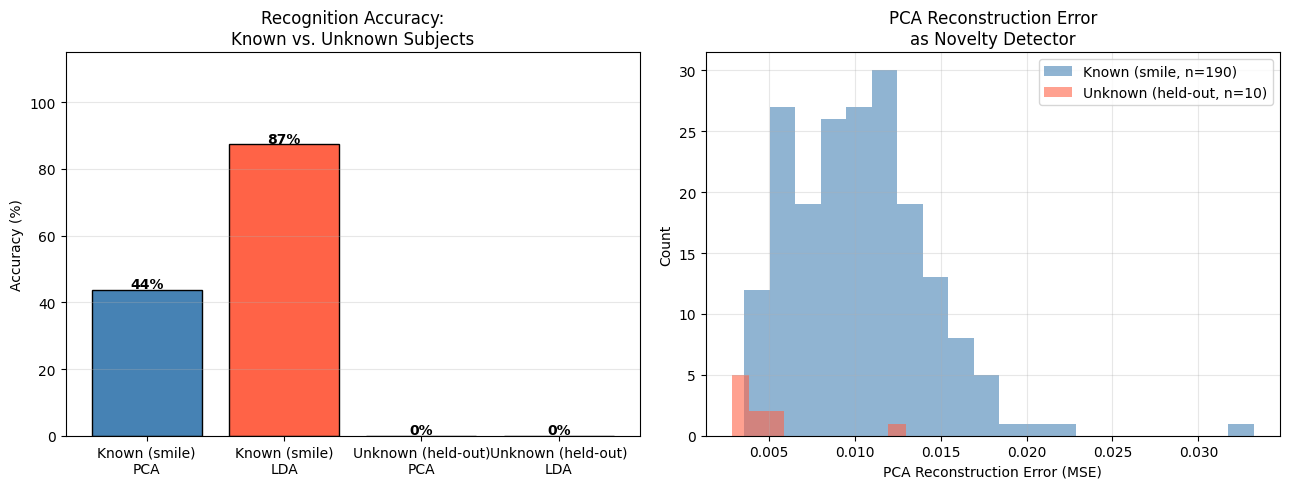

Unknown subjects — PCA accuracy (forced): 0%
Unknown subjects — LDA accuracy (forced): 0%
Mean recon error known   : 0.01025
Mean recon error unknown : 0.00495


In [ ]:
# Known subjects: smiling images of training people
# Unknown subjects: neutral images of held-out 10 people

X_unk_c    = X_neutral_test - mean_face
Z_unk_pca  = pca.transform(X_unk_c)
Z_unk_lda  = fisher_transform(X_neutral_test)

# Measure how confident each method is
# i.e. reconstruction error for PCA vs. minimum Fisher distance
# Also show accuracy on known (should be high) vs. unknown (forced choice, should be random ~0.5%)

def pca_reconstruction_error(X_c, pca_model, k):
    W = pca_model.components_[:k]           # (k, D)
    coords = X_c @ W.T                      # (N, k)
    recon  = coords @ W + mean_face         # (N, D)
    mse    = np.mean((X_c + mean_face - recon)**2, axis=1)
    return mse

k_use = k95  # use 95% variance components
err_known   = pca_reconstruction_error(X_smile_c,  pca, k_use)
err_unknown = pca_reconstruction_error(X_unk_c,    pca, k_use)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy comparison
acc_unk_pca = nearest_neighbor_accuracy(Z_train_pca, y_train, Z_unk_pca, y_test_unknown)
acc_unk_lda = nearest_neighbor_accuracy(Z_train_lda, y_train, Z_unk_lda, y_test_unknown)

labels = ['Known (smile)\nPCA', 'Known (smile)\nLDA',
          'Unknown (held-out)\nPCA', 'Unknown (held-out)\nLDA']
values = [acc_pca_exp*100, acc_lda_exp*100, acc_unk_pca*100, acc_unk_lda*100]
bar_colors = ['steelblue', 'tomato', 'cornflowerblue', 'salmon']
axes[0].bar(labels, values, color=bar_colors, edgecolor='black')
for i, v in enumerate(values):
    axes[0].text(i, v+0.5, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Recognition Accuracy:\nKnown vs. Unknown Subjects')
axes[0].set_ylim(0, 115)
axes[0].grid(axis='y', alpha=0.3)

# PCA reconstruction error as novelty detector
axes[1].hist(err_known,   bins=20, alpha=0.6, label=f'Known (smile, n={len(err_known)})',   color='steelblue')
axes[1].hist(err_unknown, bins=10, alpha=0.6, label=f'Unknown (held-out, n={len(err_unknown)})', color='tomato')
axes[1].set_xlabel('PCA Reconstruction Error (MSE)')
axes[1].set_ylabel('Count')
axes[1].set_title('PCA Reconstruction Error\nas Novelty Detector')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Unknown subjects — PCA accuracy (forced): {acc_unk_pca*100:.0f}%')
print(f'Unknown subjects — LDA accuracy (forced): {acc_unk_lda*100:.0f}%')
print(f'Mean recon error known   : {err_known.mean():.5f}')
print(f'Mean recon error unknown : {err_unknown.mean():.5f}')

## Experiment 3: Accuracy vs. Number of Components

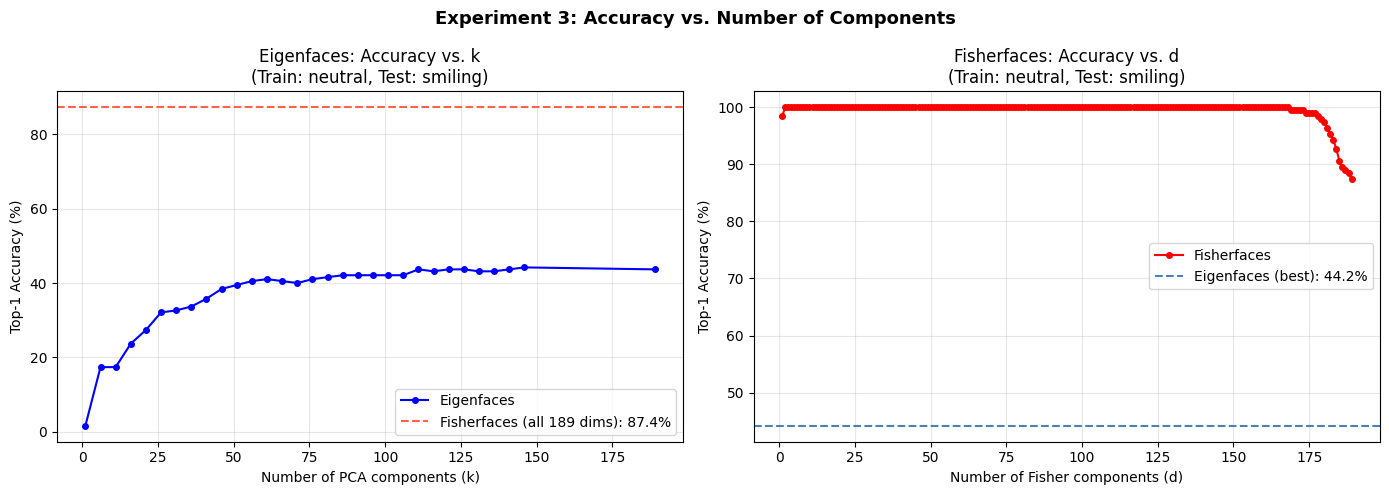

In [ ]:
# Sweep k (number of PCA components) and d (number of LDA components)
k_values = list(range(1, min(N_PCA, 150), 5)) + [N_PCA]
d_values = list(range(1, N_LDA_DIMS + 1))

acc_pca_vs_k = []
for k in k_values:
    Z_gal = Z_train_pca[:, :k]
    Z_prb = Z_smile_pca[:, :k]
    acc_pca_vs_k.append(nearest_neighbor_accuracy(Z_gal, y_train, Z_prb, y_test_known) * 100)

acc_lda_vs_d = []
for d in d_values:
    # Use first d Fisher directions
    Z_gal = Z_train_lda[:, :d]
    Z_prb = Z_smile_lda[:, :d]
    acc_lda_vs_d.append(nearest_neighbor_accuracy(Z_gal, y_train, Z_prb, y_test_known) * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_values, acc_pca_vs_k, 'b-o', markersize=4, label='Eigenfaces')
ax1.axhline(acc_lda_vs_d[-1], color='tomato', linestyle='--',
            label=f'Fisherfaces (all {N_LDA_DIMS} dims): {acc_lda_vs_d[-1]:.1f}%')
ax1.set_xlabel('Number of PCA components (k)')
ax1.set_ylabel('Top-1 Accuracy (%)')
ax1.set_title('Eigenfaces: Accuracy vs. k\n(Train: neutral, Test: smiling)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(d_values, acc_lda_vs_d, 'r-o', markersize=4, label='Fisherfaces')
ax2.axhline(max(acc_pca_vs_k), color='steelblue', linestyle='--',
            label=f'Eigenfaces (best): {max(acc_pca_vs_k):.1f}%')
ax2.set_xlabel('Number of Fisher components (d)')
ax2.set_ylabel('Top-1 Accuracy (%)')
ax2.set_title('Fisherfaces: Accuracy vs. d\n(Train: neutral, Test: smiling)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Experiment 3: Accuracy vs. Number of Components', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Experiment 4: Reconstruction Quality vs. Discriminative Power

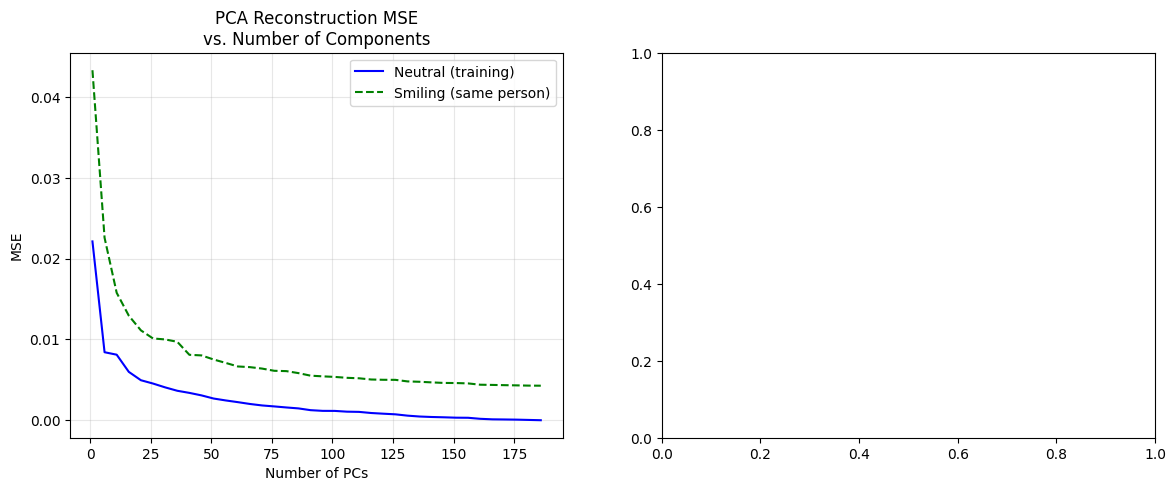

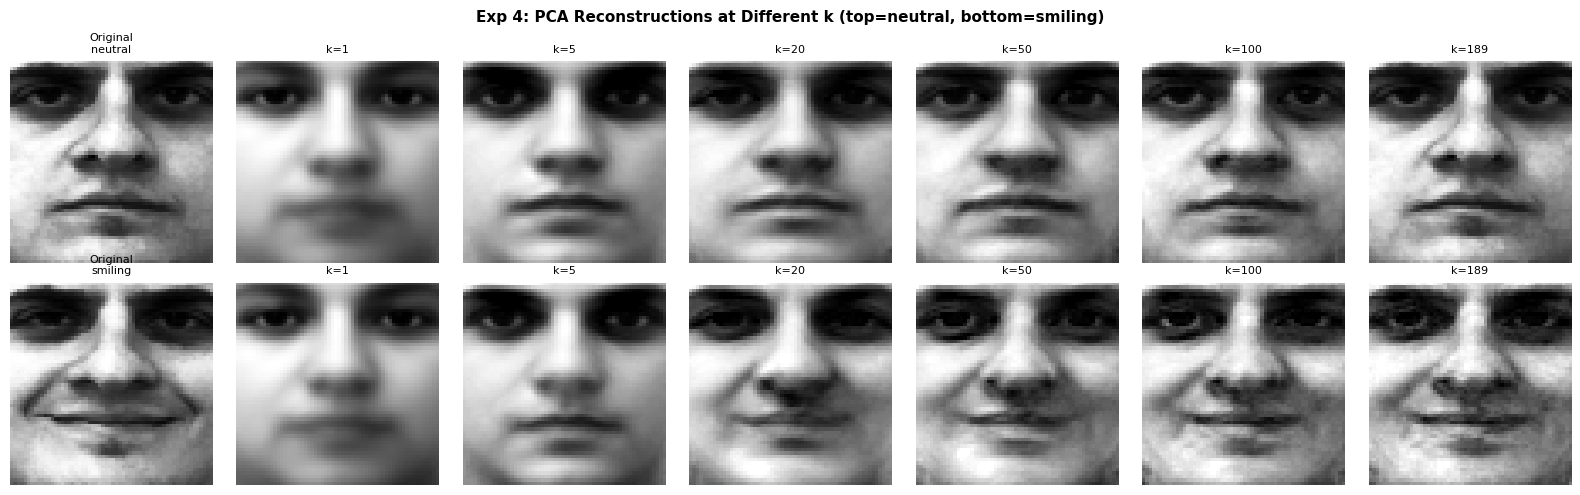

<Figure size 640x480 with 0 Axes>

In [ ]:
### 4a. PCA reconstruction MSE ###
k_range = list(range(1, N_PCA + 1, 5))

sample_idx   = 0     # person to reconstruct
x_neutral_s  = X_train[sample_idx]
x_smile_s    = X_smile_train[sample_idx]
x_neutral_sc = x_neutral_s - mean_face
x_smile_sc   = x_smile_s   - mean_face

W_all  = pca.components_   # (N_PCA, D)

mse_neutral, mse_smile = [], []
for k in k_range:
    W = W_all[:k]
    recon_n = (x_neutral_sc @ W.T) @ W + mean_face
    recon_s = (x_smile_sc   @ W.T) @ W + mean_face
    mse_neutral.append(np.mean((x_neutral_s - recon_n)**2))
    mse_smile.append(np.mean((x_smile_s - recon_s)**2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, mse_neutral, 'b-', label='Neutral (training)')
axes[0].plot(k_range, mse_smile,   'g--', label='Smiling (same person)')
axes[0].set_xlabel('Number of PCs')
axes[0].set_ylabel('MSE')
axes[0].set_title('PCA Reconstruction MSE\nvs. Number of Components')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Show actual reconstructions at different k values
k_show = [1, 5, 20, 50, 100, N_PCA]
fig2, axes2 = plt.subplots(2, len(k_show) + 1, figsize=(16, 5))
axes2[0, 0].imshow(x_neutral_s.reshape(IMG_H, IMG_W), cmap='gray')
axes2[0, 0].set_title('Original\nneutral', fontsize=8)
axes2[0, 0].axis('off')
axes2[1, 0].imshow(x_smile_s.reshape(IMG_H, IMG_W), cmap='gray')
axes2[1, 0].set_title('Original\nsmiling', fontsize=8)
axes2[1, 0].axis('off')
for j, k in enumerate(k_show):
    W = W_all[:k]
    rn = np.clip((x_neutral_sc @ W.T) @ W + mean_face, 0, 1)
    rs = np.clip((x_smile_sc   @ W.T) @ W + mean_face, 0, 1)
    axes2[0, j+1].imshow(rn.reshape(IMG_H, IMG_W), cmap='gray')
    axes2[0, j+1].set_title(f'k={k}', fontsize=8)
    axes2[0, j+1].axis('off')
    axes2[1, j+1].imshow(rs.reshape(IMG_H, IMG_W), cmap='gray')
    axes2[1, j+1].set_title(f'k={k}', fontsize=8)
    axes2[1, j+1].axis('off')
plt.suptitle('Exp 4: PCA Reconstructions at Different k (top=neutral, bottom=smiling)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# MSE comparison: accuracy vs reconstruction
axes[1].plot(k_values, acc_pca_vs_k, 'b-o', markersize=3, label='PCA Accuracy (%)')
ax_r = axes[1].twinx()
k_mse_interp = [k_range[np.argmin(np.abs(np.array(k_range) - k))] for k in k_values]
mse_at_k = [mse_neutral[k_range.index(k)] if k in k_range else np.nan for k in k_mse_interp]
ax_r.plot(k_values, mse_at_k, 'g--o', markersize=3, label='Recon MSE (neutral)')
axes[1].set_xlabel('Number of PCs (k)')
axes[1].set_ylabel('Accuracy (%)', color='b')
ax_r.set_ylabel('MSE', color='g')
axes[1].set_title('PCA: Recognition Accuracy vs. Reconstruction MSE')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='center right')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

torch 2.10.0+cpu OK
Using device: cpu


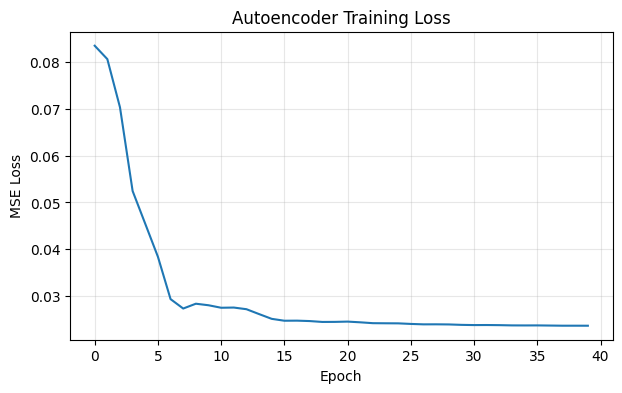

Autoencoder trained.


In [ ]:
### 4b. Autoencoder ###
# NOTE: Restart kernel if 'torch._dynamo circular import' error pops up

import torch, torch.nn as nn, torch.optim as optim

# Checking if torch is imported properly
try:
    _t = torch.tensor([1.0])
    _ = _t * 2
    print(f'torch {torch.__version__} OK')
except Exception as e:
    raise RuntimeError(
        f'PyTorch is broken ({e}). Go to Runtime → Restart session '
        'then re-run all cells.'
    ) from e

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

LATENT_DIM = 64

class FaceAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, input_dim),  nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


ae = FaceAutoencoder(IMG_FLAT, LATENT_DIM)
ae = ae.to(device)


optimizer = optim.Adam(list(ae.parameters()), lr=1e-3)
criterion = nn.MSELoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)

EPOCHS = 40
ae.train()
losses = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    recon, _ = ae(X_train_t)
    loss = criterion(recon, X_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f'  Epoch {epoch+1}/{EPOCHS}  Loss: {loss.item():.5f}')

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss')
plt.grid(alpha=0.3)
plt.show()
print('Autoencoder trained.')

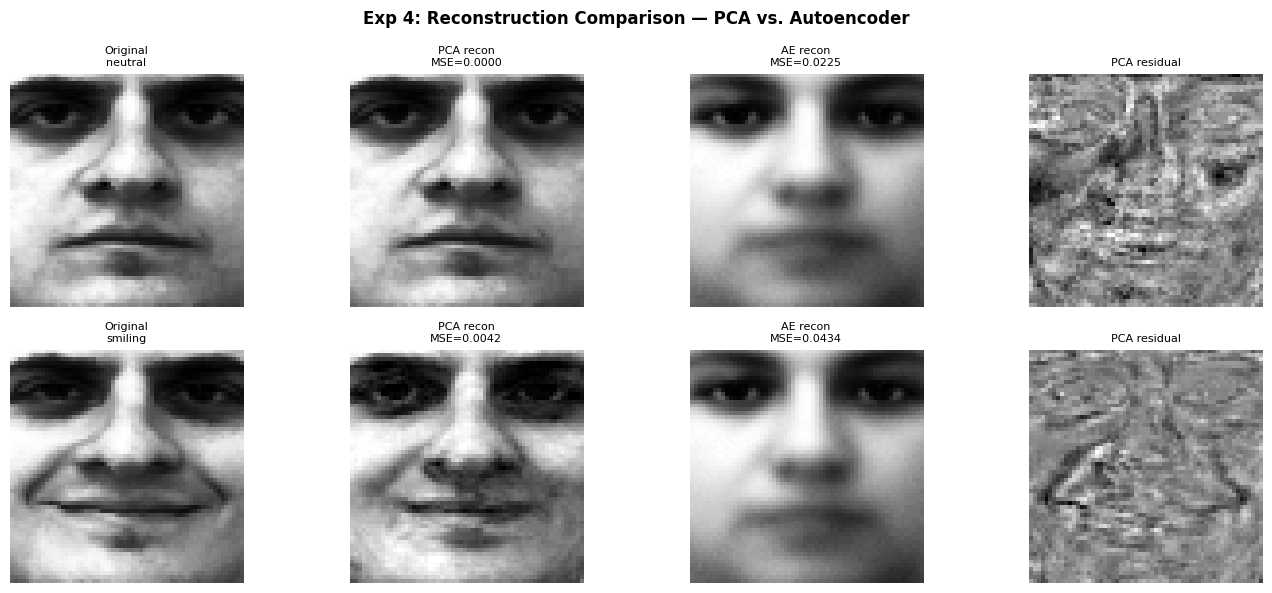


--- Summary: Expression Change Recognition ---
Eigenfaces  accuracy: 43.7%
Fisherfaces accuracy: 87.4%
Autoencoder accuracy: 6.3%

--- Reconstruction MSE (neutral) ---
PCA (all 189 PCs): 0.00000
Autoencoder (latent=64): 0.02251


In [ ]:
### 4c. Compare reconstruction: PCA vs. Autoencoder ###
ae.eval()
with torch.no_grad():
    x_t = torch.tensor(X_train[[sample_idx]], dtype=torch.float32).to(device)
    ae_recon_n, _ = ae(x_t)
    ae_recon_n = ae_recon_n.cpu().numpy().squeeze()

    xs_t = torch.tensor(X_smile_train[[sample_idx]], dtype=torch.float32).to(device)
    ae_recon_s, _ = ae(xs_t)
    ae_recon_s = ae_recon_s.cpu().numpy().squeeze()

pca_recon_n_full = np.clip((x_neutral_sc @ W_all.T) @ W_all + mean_face, 0, 1)
pca_recon_s_full = np.clip((x_smile_sc   @ W_all.T) @ W_all + mean_face, 0, 1)

mse_pca_n = np.mean((x_neutral_s - pca_recon_n_full)**2)
mse_pca_s = np.mean((x_smile_s   - pca_recon_s_full)**2)
mse_ae_n  = np.mean((X_train[sample_idx] - ae_recon_n)**2)
mse_ae_s  = np.mean((X_smile_train[sample_idx] - ae_recon_s)**2)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
pairs = [
    (x_neutral_s, 'Original\nneutral'),
    (pca_recon_n_full, f'PCA recon\nMSE={mse_pca_n:.4f}'),
    (ae_recon_n, f'AE recon\nMSE={mse_ae_n:.4f}'),
    (x_neutral_s - pca_recon_n_full + 0.5, 'PCA residual'),
    (x_smile_s, 'Original\nsmiling'),
    (pca_recon_s_full, f'PCA recon\nMSE={mse_pca_s:.4f}'),
    (ae_recon_s, f'AE recon\nMSE={mse_ae_s:.4f}'),
    (x_smile_s - pca_recon_s_full + 0.5, 'PCA residual'),
]
for ax, (img, title) in zip(axes.flatten(), pairs):
    ax.imshow(np.clip(img, 0, 1).reshape(IMG_H, IMG_W), cmap='gray')
    ax.set_title(title, fontsize=8)
    ax.axis('off')
plt.suptitle('Exp 4: Reconstruction Comparison — PCA vs. Autoencoder', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Recognition accuracy of autoencoder latent space
ae.eval()
with torch.no_grad():
    Z_train_ae = ae.encoder(X_train_t).cpu().numpy()
    xs_all_t   = torch.tensor(X_smile_train, dtype=torch.float32).to(device)
    Z_smile_ae = ae.encoder(xs_all_t).cpu().numpy()

acc_ae = nearest_neighbor_accuracy(Z_train_ae, y_train, Z_smile_ae, y_test_known)

print(f'\n--- Summary: Expression Change Recognition ---')
print(f'Eigenfaces  accuracy: {acc_pca_exp*100:.1f}%')
print(f'Fisherfaces accuracy: {acc_lda_exp*100:.1f}%')
print(f'Autoencoder accuracy: {acc_ae*100:.1f}%')
print(f'\n--- Reconstruction MSE (neutral) ---')
print(f'PCA (all {N_PCA} PCs): {mse_pca_n:.5f}')
print(f'Autoencoder (latent={LATENT_DIM}): {mse_ae_n:.5f}')

## Experiment 5: Robustness to Rotation

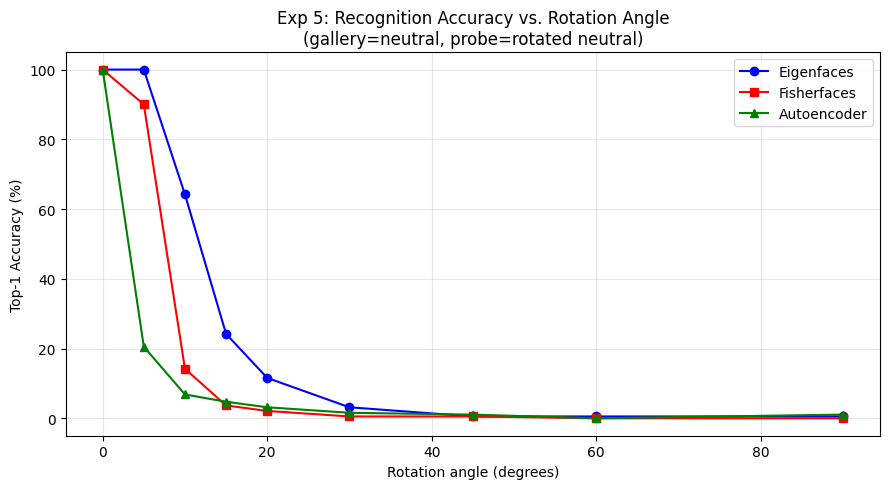

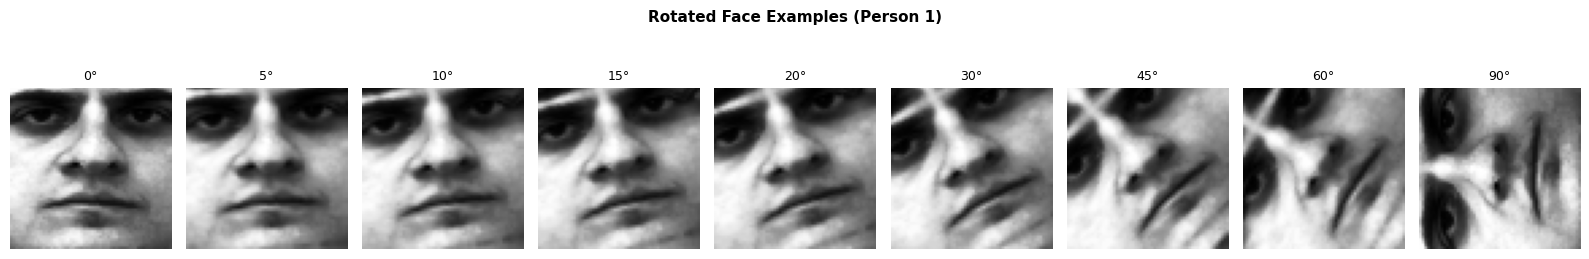

In [ ]:
def rotate_images(X, angle_deg, h=IMG_H, w=IMG_W):
    """Rotate a batch of flattened images by angle_deg."""
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    rotated = []
    for x in X:
        img = x.reshape(h, w)
        rot = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REFLECT)
        rotated.append(rot.flatten())
    return np.array(rotated, dtype=np.float32)

angles = [0, 5, 10, 15, 20, 30, 45, 60, 90]

acc_pca_rot, acc_lda_rot, acc_ae_rot = [], [], []

for angle in angles:
    X_rot = rotate_images(X_neutral[:N_TRAIN], angle)
    X_rot_c = X_rot - mean_face

    Z_rot_pca = pca.transform(X_rot_c)
    Z_rot_lda = fisher_transform(X_rot)
    with torch.no_grad():
        Z_rot_ae = ae.encoder(
            torch.tensor(X_rot, dtype=torch.float32).to(device)
        ).cpu().numpy()

    acc_pca_rot.append(nearest_neighbor_accuracy(Z_train_pca, y_train, Z_rot_pca, y_train) * 100)
    acc_lda_rot.append(nearest_neighbor_accuracy(Z_train_lda, y_train, Z_rot_lda, y_train) * 100)
    acc_ae_rot.append( nearest_neighbor_accuracy(Z_train_ae,  y_train, Z_rot_ae,  y_train) * 100)

plt.figure(figsize=(9, 5))
plt.plot(angles, acc_pca_rot, 'b-o', label='Eigenfaces')
plt.plot(angles, acc_lda_rot, 'r-s', label='Fisherfaces')
plt.plot(angles, acc_ae_rot,  'g-^', label='Autoencoder')
plt.xlabel('Rotation angle (degrees)')
plt.ylabel('Top-1 Accuracy (%)')
plt.title('Exp 5: Recognition Accuracy vs. Rotation Angle\n(gallery=neutral, probe=rotated neutral)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show rotated images
fig, axes = plt.subplots(1, len(angles), figsize=(16, 3))
for ax, angle in zip(axes, angles):
    rot = rotate_images(X_neutral[[0]], angle)[0]
    ax.imshow(rot.reshape(IMG_H, IMG_W), cmap='gray')
    ax.set_title(f'{angle}°', fontsize=9)
    ax.axis('off')
plt.suptitle('Rotated Face Examples (Person 1)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Experiment 6: 2D Subspace Visualization

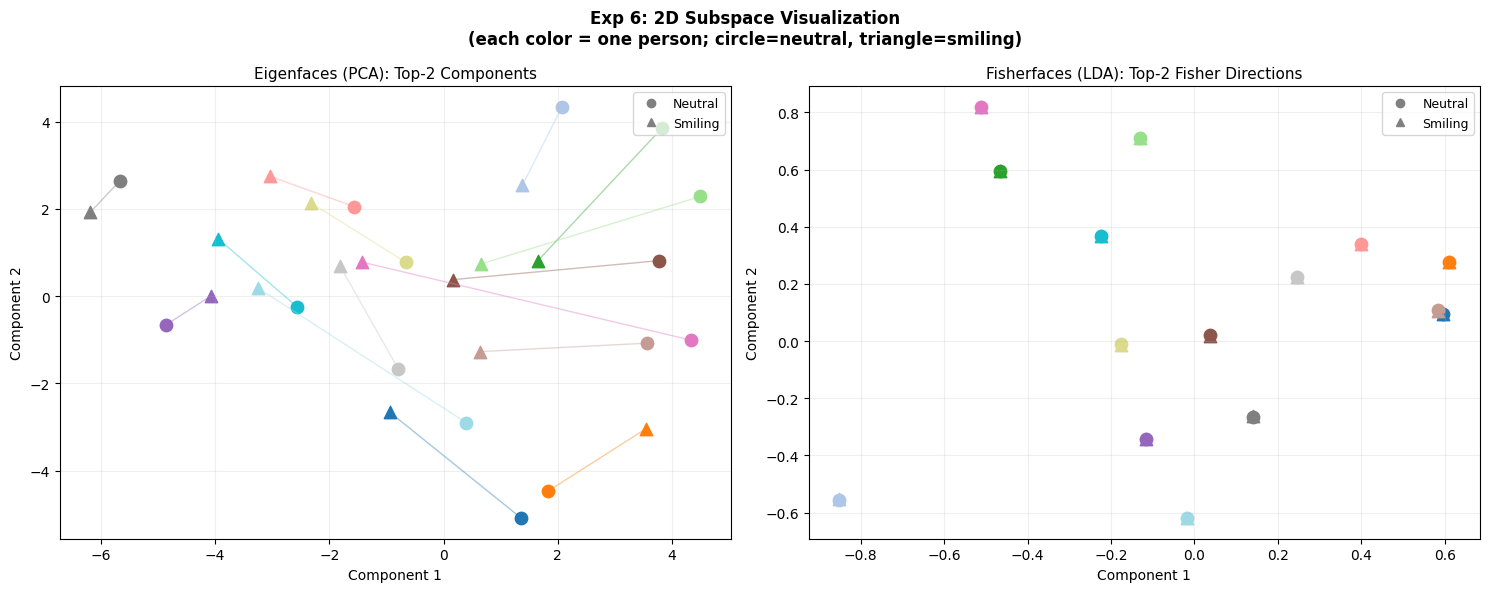

In a well-separated Fisher subspace, same-person points (circle+triangle of same color)
should cluster together, while different-person clusters spread apart.


In [ ]:
# Project all 380 images (190 neutral + 190 smiling) into 2D
# Use first 10 people for a readable plot
N_VIZ = 15   # people to visualise
COLORS = plt.cm.tab20(np.linspace(0, 1, N_VIZ))

X_all_viz   = np.vstack([X_neutral[:N_VIZ], X_smiling[:N_VIZ]])
y_all_viz   = np.hstack([y_all[:N_VIZ],     y_all[:N_VIZ]])
expr_labels = ['neutral'] * N_VIZ + ['smiling'] * N_VIZ

X_all_viz_c = X_all_viz - mean_face
Z_all_pca2  = pca.transform(X_all_viz_c)[:, :2]
Z_all_lda2  = fisher_transform(X_all_viz)[:, :2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for pid in range(N_VIZ):
    mask_n = (y_all_viz == pid) & (np.array(expr_labels) == 'neutral')
    mask_s = (y_all_viz == pid) & (np.array(expr_labels) == 'smiling')
    c = COLORS[pid]

    ax1.scatter(Z_all_pca2[mask_n, 0], Z_all_pca2[mask_n, 1],
                color=c, marker='o', s=80, label=f'P{pid+1}' if pid < 5 else '')
    ax1.scatter(Z_all_pca2[mask_s, 0], Z_all_pca2[mask_s, 1],
                color=c, marker='^', s=80)
    ax1.plot([Z_all_pca2[mask_n, 0], Z_all_pca2[mask_s, 0]],
             [Z_all_pca2[mask_n, 1], Z_all_pca2[mask_s, 1]],
             color=c, alpha=0.4, linewidth=1)

    ax2.scatter(Z_all_lda2[mask_n, 0], Z_all_lda2[mask_n, 1],
                color=c, marker='o', s=80)
    ax2.scatter(Z_all_lda2[mask_s, 0], Z_all_lda2[mask_s, 1],
                color=c, marker='^', s=80)
    ax2.plot([Z_all_lda2[mask_n, 0], Z_all_lda2[mask_s, 0]],
             [Z_all_lda2[mask_n, 1], Z_all_lda2[mask_s, 1]],
             color=c, alpha=0.4, linewidth=1)

for ax, title in [(ax1, 'Eigenfaces (PCA): Top-2 Components'),
                  (ax2, 'Fisherfaces (LDA): Top-2 Fisher Directions')]:
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    # legend for marker shapes
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], marker='o', color='gray', linestyle='', label='Neutral'),
               Line2D([0], [0], marker='^', color='gray', linestyle='', label='Smiling')]
    ax.legend(handles=handles, loc='upper right', fontsize=9)
    ax.grid(alpha=0.2)

plt.suptitle('Exp 6: 2D Subspace Visualization\n(each color = one person; circle=neutral, triangle=smiling)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('In a well-separated Fisher subspace, same-person points (circle+triangle of same color)')
print('should cluster together, while different-person clusters spread apart.')

## Final Summary Dashboard

In [ ]:
print('=' * 60)
print('FINAL SUMMARY: Eigenfaces vs. Fisherfaces vs. Autoencoder')
print('=' * 60)
print(f'\nExp 1 — Expression change (neutral→smile, 190 people):')
print(f'  Eigenfaces  : {acc_pca_exp*100:.1f}%')
print(f'  Fisherfaces : {acc_lda_exp*100:.1f}%')
print(f'  Autoencoder : {acc_ae*100:.1f}%')

print(f'\nExp 2 — Known vs. Unknown (forced nearest-neighbour):')
print(f'  Eigenfaces  known: {acc_pca_exp*100:.1f}%  |  unknown: {acc_unk_pca*100:.1f}%')
print(f'  Fisherfaces known: {acc_lda_exp*100:.1f}%  |  unknown: {acc_unk_lda*100:.1f}%')

print(f'\nExp 3 — Best accuracy across all k/d values:')
print(f'  Eigenfaces  best k: {k_values[np.argmax(acc_pca_vs_k)]}  acc={max(acc_pca_vs_k):.1f}%')
print(f'  Fisherfaces best d: {d_values[np.argmax(acc_lda_vs_d)]}  acc={max(acc_lda_vs_d):.1f}%')

print(f'\nExp 4 — Reconstruction MSE (full PCs / latent={LATENT_DIM}):')
print(f'  PCA neutral  MSE: {mse_pca_n:.5f}')
print(f'  PCA smiling  MSE: {mse_pca_s:.5f}')
print(f'  AE  neutral  MSE: {mse_ae_n:.5f}')
print(f'  AE  smiling  MSE: {mse_ae_s:.5f}')

print(f'\nExp 5 — Accuracy at 30° rotation:')
idx30 = angles.index(30)
print(f'  Eigenfaces  : {acc_pca_rot[idx30]:.1f}%')
print(f'  Fisherfaces : {acc_lda_rot[idx30]:.1f}%')
print(f'  Autoencoder : {acc_ae_rot[idx30]:.1f}%')
print('=' * 60)

FINAL SUMMARY: Eigenfaces vs. Fisherfaces vs. Autoencoder

Exp 1 — Expression change (neutral→smile, 190 people):
  Eigenfaces  : 43.7%
  Fisherfaces : 87.4%
  Autoencoder : 6.3%

Exp 2 — Known vs. Unknown (forced nearest-neighbour):
  Eigenfaces  known: 43.7%  |  unknown: 0.0%
  Fisherfaces known: 87.4%  |  unknown: 0.0%

Exp 3 — Best accuracy across all k/d values:
  Eigenfaces  best k: 146  acc=44.2%
  Fisherfaces best d: 2  acc=100.0%

Exp 4 — Reconstruction MSE (full PCs / latent=64):
  PCA neutral  MSE: 0.00000
  PCA smiling  MSE: 0.00420
  AE  neutral  MSE: 0.02251
  AE  smiling  MSE: 0.04342

Exp 5 — Accuracy at 30° rotation:
  Eigenfaces  : 3.2%
  Fisherfaces : 0.5%
  Autoencoder : 1.6%
